# Tech Challenge — Fase 4
## Etapa 2: Desenvolvimento do Modelo LSTM

Este notebook cobre o **ponto 2** do desafio: construir, treinar e avaliar uma
rede neural **LSTM** para prever o preço de fechamento das ações.

Pré-requisito: ter executado o notebook da **Etapa 1**, que gerou os artefatos
na pasta `artifacts/` (`X_train.npy`, `y_train.npy`, `X_valid.npy`, `y_valid.npy`,
`scaler.pkl`, `meta.pkl`).

Fluxo:
1. Carregar os artefatos da Etapa 1
2. Construir a arquitetura LSTM (Keras/TensorFlow)
3. Treinar com callbacks (EarlyStopping + ReduceLROnPlateau)
4. Avaliar com MAE, RMSE e MAPE (na escala real de preço)
5. Visualizar previsto vs. real e a curva de loss
6. Salvar o modelo treinado (Etapa 3)


## 0. Instalação e imports

A LSTM aqui usa TensorFlow/Keras. Descomente a instalação se necessário.

In [2]:
# !pip install tensorflow scikit-learn pandas numpy matplotlib joblib

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

ARTIFACTS_DIR = "artifacts"
print("TensorFlow:", tf.__version__)

I0000 00:00:1782077199.926355   19858 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782077200.006491   19858 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782077207.831287   19858 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0


## 1. Carregar os Artefatos da Etapa 1

Recuperamos os arrays já janelados, o scaler e os metadados.

In [3]:
X_train = np.load(os.path.join(ARTIFACTS_DIR, "X_train.npy"))
y_train = np.load(os.path.join(ARTIFACTS_DIR, "y_train.npy"))
X_valid = np.load(os.path.join(ARTIFACTS_DIR, "X_valid.npy"))
y_valid = np.load(os.path.join(ARTIFACTS_DIR, "y_valid.npy"))

scaler = joblib.load(os.path.join(ARTIFACTS_DIR, "scaler.pkl"))
meta = joblib.load(os.path.join(ARTIFACTS_DIR, "meta.pkl"))

WINDOW_SIZE = meta["window_size"]
SYMBOL = meta["symbol"]

print(f"Símbolo: {SYMBOL} | Janela: {WINDOW_SIZE}")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_valid:", X_valid.shape, "| y_valid:", y_valid.shape)

Símbolo: AAPL | Janela: 60
X_train: (1641, 60, 1) | y_train: (1641,)
X_valid: (426, 60, 1) | y_valid: (426,)


## 2. Construção da Arquitetura LSTM

Arquitetura empilhada (stacked LSTM) com regularização por Dropout:

- **LSTM 1** (`return_sequences=True`) — captura padrões e passa a sequência adiante
- **Dropout** — reduz overfitting
- **LSTM 2** — consolida a representação temporal
- **Dropout**
- **Dense** — saída única (o preço previsto, escalonado em 0–1)

O alvo está em escala 0–1, então a saída é linear (sem ativação).

In [4]:
def build_model(window_size, n_features=1, units=(64, 32), dropout=0.2, lr=1e-3):
    model = Sequential([
        Input(shape=(window_size, n_features)),
        LSTM(units[0], return_sequences=True),
        Dropout(dropout),
        LSTM(units[1], return_sequences=False),
        Dropout(dropout),
        Dense(16, activation="relu"),
        Dense(1),  # previsão do preço (escala 0-1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="mean_squared_error",
        metrics=["mae"],
    )
    return model

model = build_model(WINDOW_SIZE)
model.summary()

E0000 00:00:1782077229.499608   19858 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Treinamento

Usamos callbacks para um treino robusto:

- **EarlyStopping** — para quando a `val_loss` deixa de melhorar e restaura os melhores pesos
- **ReduceLROnPlateau** — reduz o learning rate ao estagnar, refinando a convergência
- **ModelCheckpoint** — salva o melhor modelo durante o treino

Como é série temporal, **não** embaralhamos: `shuffle=False`.

In [5]:
os.makedirs("models", exist_ok=True)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-5),
    ModelCheckpoint("models/lstm_best.keras", monitor="val_loss",
                    save_best_only=True),
]

EPOCHS = 100
BATCH_SIZE = 32

history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=False,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - loss: 0.0088 - mae: 0.0714 - val_loss: 0.0282 - val_mae: 0.1439 - learning_rate: 0.0010
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.0089 - mae: 0.0754 - val_loss: 0.0061 - val_mae: 0.0654 - learning_rate: 0.0010
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0060 - mae: 0.0585 - val_loss: 0.0025 - val_mae: 0.0386 - learning_rate: 0.0010
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.0054 - mae: 0.0575 - val_loss: 0.0041 - val_mae: 0.0536 - learning_rate: 0.0010
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0031 - mae: 0.0444 - val_loss: 0.0034 - val_mae: 0.0461 - learning_rate: 0.0010
Epoch 6/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0036 - mae: 0.0474 - val_loss: 0.0020 - val_mae: 0.0351 - learning_rate: 0.0010
Epoch 7/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0029 - mae: 0.0414 - val_loss: 0.0024 - val_mae: 0.0379 - learning_rate: 0.0010
Epoch 

## 4. Avaliação

**Importante:** as métricas precisam ser calculadas na **escala real de preço**,
não na escala 0–1. Por isso aplicamos `scaler.inverse_transform` antes de medir.

In [6]:
# Previsões (escala 0-1)
y_pred_scaled = model.predict(X_valid)

# Reverter para a escala real de preço
y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
y_true = scaler.inverse_transform(y_valid.reshape(-1, 1)).flatten()

# Métricas
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step
MAE  : 6.9577
RMSE : 8.7795
MAPE : 2.89%


## 5. Visualizações

### 5.1 Previsto vs. Real

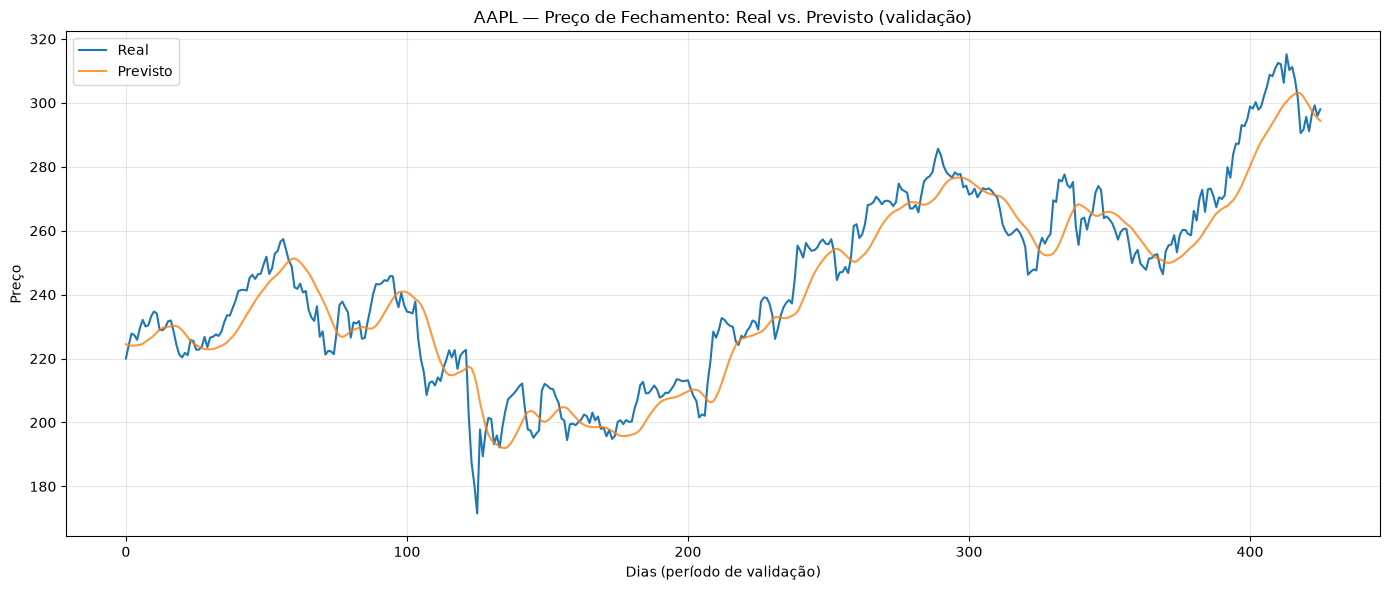

In [7]:
plt.figure(figsize=(14, 6))
plt.plot(y_true, label="Real", linewidth=1.5)
plt.plot(y_pred, label="Previsto", linewidth=1.5, alpha=0.8)
plt.title(f"{SYMBOL} — Preço de Fechamento: Real vs. Previsto (validação)")
plt.xlabel("Dias (período de validação)")
plt.ylabel("Preço")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2 Curva de aprendizado (loss)

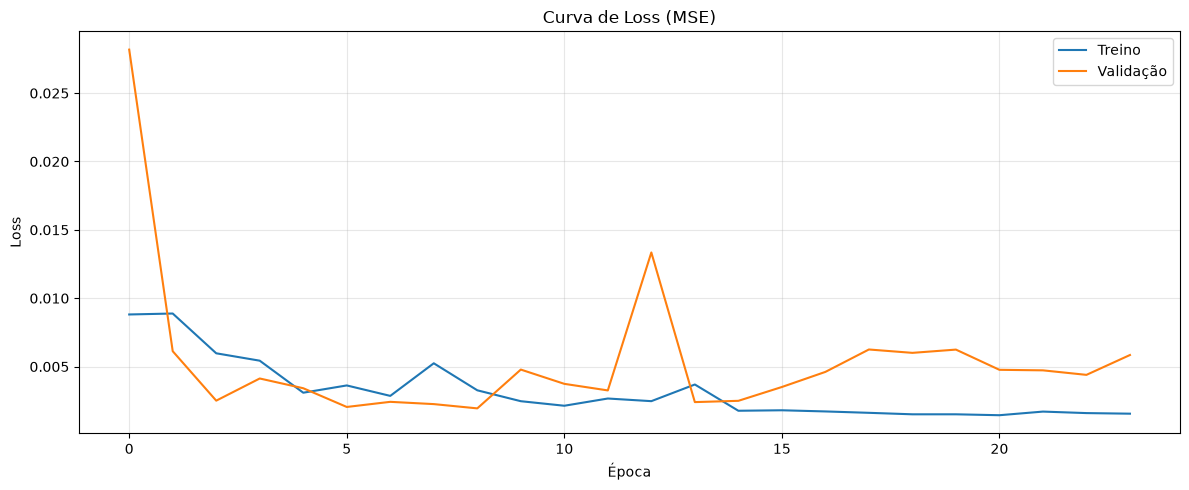

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validação")
plt.title("Curva de Loss (MSE)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Salvar o Modelo Treinado (Etapa 3)

O `ModelCheckpoint` já salvou o melhor modelo, mas salvamos também a versão final
e registramos as métricas para rastreabilidade. Este `.keras` é o que a **API
da Etapa 4** vai carregar para inferência.

In [9]:
# Salva o modelo final (com os melhores pesos restaurados pelo EarlyStopping)
model.save("models/lstm_final.keras")

# Registra as métricas junto aos metadados
metrics = {"MAE": float(mae), "RMSE": float(rmse), "MAPE_pct": float(mape)}
joblib.dump(metrics, os.path.join(ARTIFACTS_DIR, "metrics.pkl"))

print("Modelo salvo em: models/lstm_final.keras")
print("Melhor checkpoint: models/lstm_best.keras")
print("Métricas:", metrics)

Modelo salvo em: models/lstm_final.keras
Melhor checkpoint: models/lstm_best.keras
Métricas: {'MAE': 6.95771338234485, 'RMSE': 8.779454931857618, 'MAPE_pct': 2.8902808501515564}


## Pronto ✅

Etapa 2 (e parte da 3) concluída:

- Modelo LSTM construído, treinado e avaliado com **MAE**, **RMSE** e **MAPE**
- Métricas calculadas na escala real de preço (sem leakage do scaler)
- Modelo salvo em `models/lstm_final.keras`

**Próximos passos:**
- Etapa 4: criar a API (FastAPI) que carrega `lstm_final.keras` + `scaler.pkl`,
  recebe os últimos N preços e devolve a previsão
- Etapa 5: empacotar em Docker e adicionar monitoramento (tempo de resposta, recursos)

**Dicas de ajuste de hiperparâmetros**, caso queira melhorar o desempenho:
- Aumentar/diminuir `units` das LSTMs e a `WINDOW_SIZE` (na Etapa 1)
- Ajustar `dropout` (0.1–0.3) para controlar overfitting
- Testar `learning_rate` (1e-3 a 1e-4) e `batch_size` (16, 32, 64)
